# Credit at Risk: constructing operator $A$ for a correlated portfolio

### The next piece after VaR + Amplitude Estimation

This notebook continues `03_var_with_amplitude_estimation.ipynb`.
There we saw that VaR is a **quantile**, that every quantile is a level of a **CDF**,
and that the CDF value $a = P(L \le x)$ is exactly an **amplitude** that QAE can estimate.

Here we finally show **how to build the operator $A$** that prepares that amplitude
for a **credit portfolio of many correlated assets** -- the concrete circuit pieces
$U$, $S$, $C$ that the paper puts together.

**One-sentence preview**

> $U$ creates economic scenarios -> default indicators $X_k$ -> $S$ sums the losses ->
> $C$ asks "is $L \le x$?" -> AE estimates how often the answer is yes -> search the
> smallest $x$ with that probability $\ge \alpha$ -> that $x$ is $\mathrm{VaR}_\alpha$.

**Roadmap**

1. The problem: total loss of $K$ assets
2. What VaR means (again, with a tiny table)
3. Why it is hard ($2^K$ scenarios)
4. Default indicators $X_k$ and losses $L_k = \lambda_k X_k$
5. Correlation via a latent factor $Z$ (the economy)
6. Formula (11): $p_k(z) = P(X_k=1\mid Z=z)$
7. The quantum circuit: $Z$-register, $X$-register, sum, objective
8. Rotations $R_y$ that encode default probabilities
9. Operators $S$ (sum) and $C$ (compare)
10. Closing the loop with Amplitude Estimation
11. Full numerical toy: Monte Carlo of the one-factor model + search for VaR


## 0. Setup

In [1]:
import sys

try:
    sys.stdout.reconfigure(encoding='utf-8')
except (AttributeError, ValueError):
    pass

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.28,
    'font.size': 11,
    'axes.titlesize': 13,
})

rng = np.random.default_rng(11)
print(f'numpy {np.__version__} - ready')


numpy 1.26.4 - ready


## 1. The problem: a portfolio of $K$ assets

Imagine a credit portfolio with $K$ names (bonds, loans, counterparties, ...).
Each asset $k$ can produce a loss $L_k$. The **total loss** is just the sum:

$$
\boxed{L = L_1 + L_2 + \dots + L_K}
$$

We do **not** know $L$ in advance. Every $L_k$ is random, so $L$ has a whole
distribution of possible outcomes -- from almost nothing to a catastrophe.

```text
                    POSSIBLE SCENARIOS
                           |
             +----------------------------+
             |   L = total portfolio loss |
             +----------------------------+
                  /      |      |      \
                0    small   medium   huge
```

What we want from this distribution is the **Value at Risk**.


## 2. What is VaR? (quick reminder)

$$
\mathrm{VaR}_\alpha[L]
=
\inf_{x \ge 0}
\{\, x :\; P(L \le x) \ge \alpha \,\}
$$

In plain words:

> Find the loss level $x$ such that the probability of losing **at most** $x$
> is at least $\alpha$.

For $\alpha = 95\%$ we want the smallest $x$ with $P(L \le x) \ge 0.95$.


Example cumulative table
    Loss       CDF
     100       50%
     200       80%
     300       93%
     400       97%  <-- first CDF >= 95%
     500       99%

VaR_95% = 400


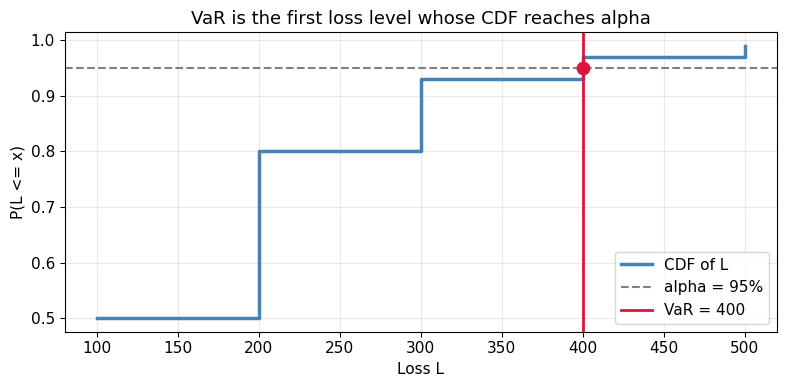

In [2]:
# Tiny didactic CDF table (same spirit as the '400 euro' example)
losses_ex = np.array([100, 200, 300, 400, 500], dtype=float)
cdf_ex = np.array([0.50, 0.80, 0.93, 0.97, 0.99])
alpha = 0.95
var_ex = losses_ex[np.where(cdf_ex >= alpha)[0][0]]

print('Example cumulative table')
print(f"{'Loss':>8}  {'CDF':>8}")
for L, c in zip(losses_ex, cdf_ex):
    mark = '  <-- first CDF >= 95%' if L == var_ex else ''
    print(f'{L:8.0f}  {c:8.0%}{mark}')
print(f'\nVaR_95% = {var_ex:.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.step(losses_ex, cdf_ex, where='post', lw=2.5, color='steelblue', label='CDF of L')
ax.axhline(alpha, color='gray', ls='--', label='alpha = 95%')
ax.axvline(var_ex, color='crimson', lw=2, label=f'VaR = {var_ex:.0f}')
ax.scatter([var_ex], [alpha], color='crimson', s=80, zorder=5)
ax.set_xlabel('Loss L')
ax.set_ylabel('P(L <= x)')
ax.set_title('VaR is the first loss level whose CDF reaches alpha')
ax.legend()
plt.tight_layout()
plt.show()


### How to read the chart

Walk along the loss axis until the cumulative probability hits 95%.
The first level that makes it is VaR. In the toy table that is **400**.

Nothing magical -- just a quantile of the loss distribution.


## 3. Why is this hard?

With many assets you must consider **all combinations of outcomes at once**.

Suppose each of 100 names is either default ($X_k=1$) or not ($X_k=0$).
Then there are

$$
2^{100} \approx 1.27 \times 10^{30}
$$

possible scenarios. You cannot enumerate them.

Classical Monte Carlo answers by sampling:

```text
draw scenario -> compute L -> repeat millions of times -> empirical CDF
```

The paper's claim is: we can estimate the same CDF values with
**Quantum Amplitude Estimation**, aiming at a quadratic query speedup
($O(1/\varepsilon)$ vs $O(1/\varepsilon^2)$ in the ideal case).


## 4. Default indicators $X_k$ and loss given default $\lambda_k$

Useful simplification from the paper: for each asset $k$,

$$
X_k \in \{0,1\}
$$

- $X_k = 0$: no default
- $X_k = 1$: default

The loss of name $k$ is then

$$
L_k = \lambda_k X_k
$$

where $\lambda_k$ is the **loss given default** (exposure at default times loss severity).

Total portfolio loss:

$$
\boxed{L = \sum_{k=1}^{K} \lambda_k X_k}
$$


Asset    lambda    X     loss
A           100    0        0
B           200    1      200
C           500    0        0
D           300    1      300
------------------------------
Total L = 500


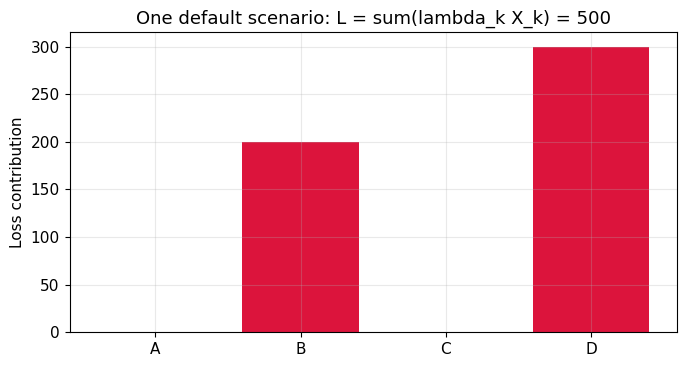

In [3]:
# Concrete 4-name example matching the didactic table
names = np.array(['A', 'B', 'C', 'D'])
lambdas = np.array([100.0, 200.0, 500.0, 300.0])   # loss given default
X_example = np.array([0, 1, 0, 1])                  # one particular scenario

L_k = lambdas * X_example
L_tot = L_k.sum()

print(f"{'Asset':<6} {'lambda':>8} {'X':>4} {'loss':>8}")
for n, lam, x, lk in zip(names, lambdas, X_example, L_k):
    print(f'{n:<6} {lam:8.0f} {x:4d} {lk:8.0f}')
print('-' * 30)
print(f'Total L = {L_tot:.0f}')

fig, ax = plt.subplots(figsize=(7, 3.8))
colors = ['steelblue' if x == 0 else 'crimson' for x in X_example]
ax.bar(names, L_k, color=colors)
ax.set_ylabel('Loss contribution')
ax.set_title(f'One default scenario: L = sum(lambda_k X_k) = {L_tot:.0f}')
plt.tight_layout()
plt.show()


## 5. Defaults are correlated: the latent factor $Z$

You cannot pretend names default independently. In a bad economy many names
default **together**.

The paper introduces a latent variable $Z$ that stands for the **state of the
economy / market**:

```text
                Z   (economy)
                |
       +--------+--------+
       |        |        |
       v        v        v
      X1       X2       X3
```

- $Z$ very negative -> crisis -> default probabilities go **up**
- $Z$ positive -> calm markets -> default probabilities go **down**

This is the classic **one-factor Gaussian credit model** (Vasicek / Basel-style).


## 6. Formula (11): default probability given $Z=z$

$$
p_k(z)
=
\Phi\!\left(
\frac{\Phi^{-1}(p_k^0) - \sqrt{\rho_k}\, z}{\sqrt{1-\rho_k}}
\right)
$$

Scary-looking, simple meaning:

$$
\boxed{p_k(z) = P(X_k = 1 \mid Z = z)}
$$

| Symbol | Meaning |
|--------|---------|
| $p_k^0$ | unconditional ("normal") default probability of name $k$ |
| $\rho_k$ | asset correlation with the common factor $Z$ (how much it follows the economy) |
| $\Phi$ | standard normal CDF |
| $\Phi^{-1}$ | its inverse (quantile function) |

The causal chain to remember:

$$
\boxed{Z \;\rightarrow\; p_k(z) \;\rightarrow\; X_k}
$$


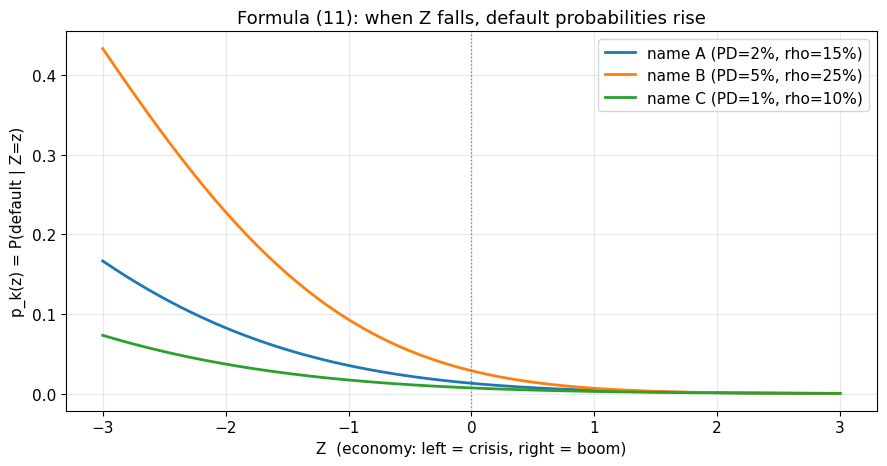

At Z = -2 (crisis):
  name A (PD=2%, rho=15%): p = 8.27%
  name B (PD=5%, rho=25%): p = 22.83%
  name C (PD=1%, rho=10%): p = 3.71%
At Z = +2 (boom):
  name A (PD=2%, rho=15%): p = 0.11%
  name B (PD=5%, rho=25%): p = 0.11%
  name C (PD=1%, rho=10%): p = 0.09%


In [4]:
# Conditional default probability p_k(z) - formula (11)
def p_default_given_z(z, p0, rho):
    z = np.asarray(z, dtype=float)
    num = norm.ppf(p0) - np.sqrt(rho) * z
    den = np.sqrt(1.0 - rho)
    return norm.cdf(num / den)

# Three names with different base PD and correlation
p0s = np.array([0.02, 0.05, 0.01])
rhos = np.array([0.15, 0.25, 0.10])
labels = [
    'name A (PD=2%, rho=15%)',
    'name B (PD=5%, rho=25%)',
    'name C (PD=1%, rho=10%)',
]

z_grid = np.linspace(-3, 3, 400)

fig, ax = plt.subplots(figsize=(9, 4.8))
for p0, rho, lab in zip(p0s, rhos, labels):
    ax.plot(z_grid, p_default_given_z(z_grid, p0, rho), lw=2, label=lab)
ax.axvline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Z  (economy: left = crisis, right = boom)')
ax.set_ylabel('p_k(z) = P(default | Z=z)')
ax.set_title('Formula (11): when Z falls, default probabilities rise')
ax.legend()
plt.tight_layout()
plt.show()

print('At Z = -2 (crisis):')
for p0, rho, lab in zip(p0s, rhos, labels):
    print(f'  {lab}: p = {p_default_given_z(-2, p0, rho):.2%}')
print('At Z = +2 (boom):')
for p0, rho, lab in zip(p0s, rhos, labels):
    print(f'  {lab}: p = {p_default_given_z(+2, p0, rho):.2%}')


### Reading this plot

Each curve is one asset. As you move left (worse economy), every curve goes up:
defaults become more likely. Names with larger $\rho$ react more strongly to $Z$
-- they are more "systemic".


## 7. The quantum circuit pieces (operator $A$)

The paper's figure for the state-preparation operator $A$ has four registers:

```text
Z-register        |0>  ---- U --------------
                          |
X-register        |0>  ---+---- (controlled Ry) ----
                          |         |
sum-register      |0>  -------------+---- S ----
                                    |
objective qubit   |0>  ------------------- C ----
```

| Piece | Role |
|-------|------|
| **Z-register** | holds the latent economy $Z$ |
| **X-register** | one qubit per name: default / no default |
| **sum-register** | stores total loss $L = \sum \lambda_k X_k$ |
| **objective qubit** | flipped to $|1\rangle$ iff $L \le x$ |

Together, $U$ (load $Z$ and prepare $X\mid Z$) + $S$ (sum) + $C$ (compare)
**are** the operator $A$ that Amplitude Estimation will query.


## 8. Z-register and operator $U$

Start from $|0\rangle_{n_Z}$ and apply $U$ so that the Z-register carries a
**discretized distribution of the economy**, and conditionally the default bits:

$$
U|0\rangle
=
\sum_z \sqrt{p_Z(z)}\, |z\rangle \otimes \bigotimes_{k=1}^{K}
\big(\sqrt{1-p_k(z)}\,|0\rangle + \sqrt{p_k(z)}\,|1\rangle\big)_k
\otimes |0\rangle_{\mathrm{sum}}
\otimes |0\rangle_{\mathrm{obj}}
$$

In words: **$U$ generates economic scenarios and, conditionally, the default
bits of every name.**


## 9. Encoding $p_k(z)$ with a $Y$-rotation (link to the previous notebook)

Exactly as in the Bernoulli Amplitude Estimation demo: to put probability $p$
on $|1\rangle$, rotate by

$$
\theta_k^p(z) = 2 \arcsin\!\big(\sqrt{p_k(z)}\big)
$$

so that

$$
\boxed{
R_y(\theta_k^p)\,|0\rangle
=
\sqrt{1-p_k(z)}\,|0\rangle
+
\sqrt{p_k(z)}\,|1\rangle
}
$$

Measuring that qubit then gives $P(X_k=1)=p_k(z)$.

The rotation is **controlled by the Z-register**, because the default probability
depends on the economy:

```text
     Z  -->  p_k(z)  -->  Ry(theta)  -->  X_k qubit
```


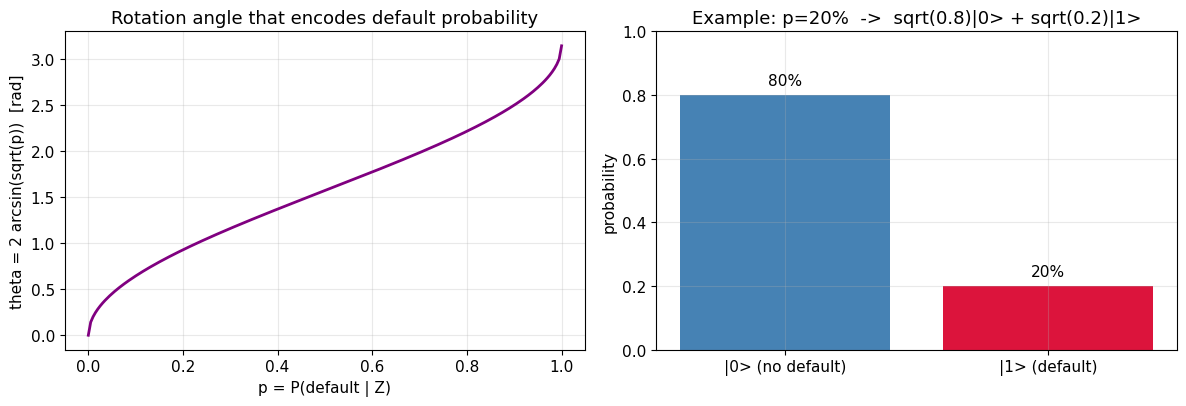

For p=20%: theta = 0.9273 rad = 53.1 deg


In [5]:
# Visual: Ry angle vs default probability
p_vals = np.linspace(0.0, 1.0, 200)
theta_vals = 2 * np.arcsin(np.sqrt(p_vals))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.plot(p_vals, theta_vals, lw=2, color='purple')
ax.set_xlabel('p = P(default | Z)')
ax.set_ylabel('theta = 2 arcsin(sqrt(p))  [rad]')
ax.set_title('Rotation angle that encodes default probability')

ax = axes[1]
p_demo = 0.20
amp0, amp1 = np.sqrt(1 - p_demo), np.sqrt(p_demo)
ax.bar(['|0> (no default)', '|1> (default)'], [amp0**2, amp1**2],
       color=['steelblue', 'crimson'])
ax.set_ylim(0, 1)
ax.set_ylabel('probability')
ax.set_title('Example: p=20%  ->  sqrt(0.8)|0> + sqrt(0.2)|1>')
for i, v in enumerate([amp0**2, amp1**2]):
    ax.text(i, v + 0.03, f'{v:.0%}', ha='center')

plt.tight_layout()
plt.show()
print(f'For p={p_demo:.0%}: theta = {2*np.arcsin(np.sqrt(p_demo)):.4f} rad '
      f'= {np.degrees(2*np.arcsin(np.sqrt(p_demo))):.1f} deg')


## 10. Operator $S$: sum the losses

After $U$ we have a superposition of default patterns
$(X_1,\ldots,X_K)$. Operator $S$ writes the total loss into the sum register:

$$
S:
|x_1,\ldots,x_K\rangle\,|0\rangle_{\mathrm{sum}}
\;\longrightarrow\;
|x_1,\ldots,x_K\rangle\,
\big|\lambda_1 x_1 + \cdots + \lambda_K x_K\big\rangle_{\mathrm{sum}}
$$

Brutal translation:

> "Look at which names defaulted and write the total loss in the sum register."


X bits         L = S(X)
[0, 0, 0, 0]          0
[1, 0, 0, 0]        100
[0, 1, 0, 0]        200
[1, 1, 0, 0]        300
[0, 0, 1, 0]        500
[1, 0, 1, 0]        600
[0, 1, 1, 0]        700
[1, 1, 1, 0]        800
[0, 0, 0, 1]        300
[1, 0, 0, 1]        400
[0, 1, 0, 1]        500
[1, 1, 0, 1]        600
[0, 0, 1, 1]        800
[1, 0, 1, 1]        900
[0, 1, 1, 1]       1000
[1, 1, 1, 1]       1100


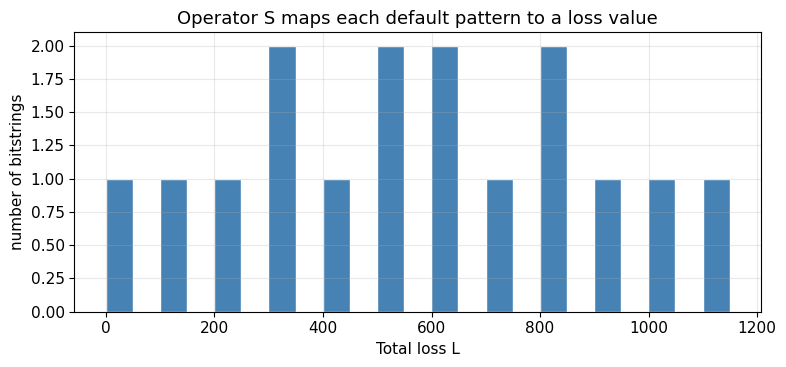

In [6]:
# Demonstrate S classically on a few bitstrings
def apply_S(X_bits, lambdas_vec):
    return float(np.dot(lambdas_vec, X_bits))

K4 = len(lambdas)
patterns = []
for mask in range(2 ** K4):
    bits = np.array([(mask >> i) & 1 for i in range(K4)])
    patterns.append((bits, apply_S(bits, lambdas)))

print(f"{'X bits':<12} {'L = S(X)':>10}")
for bits, Lv in patterns:
    print(f'{str(list(bits)):<12} {Lv:10.0f}')

Ls = np.array([Lv for _, Lv in patterns])
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(Ls, bins=np.arange(-0.5, Ls.max() + 50, 50), color='steelblue', edgecolor='white')
ax.set_xlabel('Total loss L')
ax.set_ylabel('number of bitstrings')
ax.set_title('Operator S maps each default pattern to a loss value')
plt.tight_layout()
plt.show()


## 11. Operator $C$: the comparison (objective qubit)

We want $P(L \le x)$ for a candidate threshold $x$.
Operator $C$ flips the objective qubit when the inequality holds:

$$
C:\;
|L\rangle\,|0\rangle_{\mathrm{obj}}
\;\longrightarrow\;
|L\rangle\,
|1\rangle_{\mathrm{obj}}
\quad\text{if } L \le x,
\quad
|0\rangle_{\mathrm{obj}}
\quad\text{otherwise.}
$$

```text
        total loss L
              |
              v
           +-----+
     x --->|  C  |
           +--+--+
              |
              v
        objective qubit
        L <= x  -> |1>
        L >  x  -> |0>
```

After $A = C\,S\,U$, the probability of measuring the objective qubit in $|1\rangle$
is exactly

$$
\boxed{a = P(L \le x)}
$$

-- the same amplitude we estimated in the previous notebook.


## 12. Amplitude Estimation and the search for VaR

AE estimates $a = P(L \le x)$ for a fixed threshold $x$.
VaR is the **smallest** $x$ such that $a \ge \alpha$. So we binary-search $x$:

```text
try x = 1M -> AE -> P = 60%  (too low)
try x = 2M -> AE -> P = 82%  (still low)
try x = 3M -> AE -> P = 96%  (OK for alpha=95%)
=> VaR_95% = 3M
```

The quantum computer does **not** compute VaR in one shot. It estimates CDF
values; classical search turns those into the quantile.


## 13. Full numerical toy: one-factor credit portfolio

We now simulate the **classical Monte Carlo twin** of the circuit:

1. draw $Z \sim \mathcal{N}(0,1)$ (economy)
2. for each name, set $p_k = p_k(Z)$ with formula (11)
3. draw $X_k \sim \mathrm{Bernoulli}(p_k)$
4. set $L = \sum \lambda_k X_k$
5. build the empirical CDF and read $\mathrm{VaR}_{95\%}$
6. show the same CDF-estimation + binary-search idea that AE would accelerate


In [7]:
# --- Portfolio definition -------------------------------------------------
K = 8
lambdas_pf = np.array([2.0, 3.0, 1.5, 4.0, 2.5, 3.5, 1.0, 5.0]) * 1e6   # EUR
p0 = np.array([0.02, 0.03, 0.015, 0.04, 0.025, 0.035, 0.01, 0.05])
rho = np.full(K, 0.20)   # common asset correlation
ALPHA = 0.95
N_MC = 80_000

print('Portfolio:')
print(f'  names K = {K}')
print(f'  total exposure sum(lambda) = {lambdas_pf.sum()/1e6:.1f} M EUR')
print(f'  mean PD = {p0.mean():.2%},  rho = {rho[0]:.0%}')


def simulate_losses(n, rng_local):
    # One-factor Gaussian copula / Vasicek-style defaults
    Zloc = rng_local.standard_normal(n)
    num = norm.ppf(p0)[None, :] - np.sqrt(rho)[None, :] * Zloc[:, None]
    den = np.sqrt(1.0 - rho)[None, :]
    p = norm.cdf(num / den)
    Xloc = rng_local.random((n, K)) < p
    Lloc = Xloc @ lambdas_pf
    return Zloc, Xloc, Lloc


Z, X, L = simulate_losses(N_MC, rng)
var_true = float(np.quantile(L, ALPHA))
breach = float(np.mean(L > var_true))

print(f'\nMonte Carlo ({N_MC:,} scenarios)')
print(f'  mean loss     = {L.mean()/1e6:.3f} M')
print(f'  VaR_95%       = {var_true/1e6:.3f} M')
print(f'  P(L > VaR)    = {breach:.3f}  (target ~ 0.05)')
print(f'  avg #defaults = {X.sum(axis=1).mean():.2f}')


Portfolio:
  names K = 8
  total exposure sum(lambda) = 22.5 M EUR
  mean PD = 2.81%,  rho = 20%

Monte Carlo (80,000 scenarios)
  mean loss     = 0.759 M
  VaR_95%       = 5.000 M
  P(L > VaR)    = 0.029  (target ~ 0.05)
  avg #defaults = 0.23


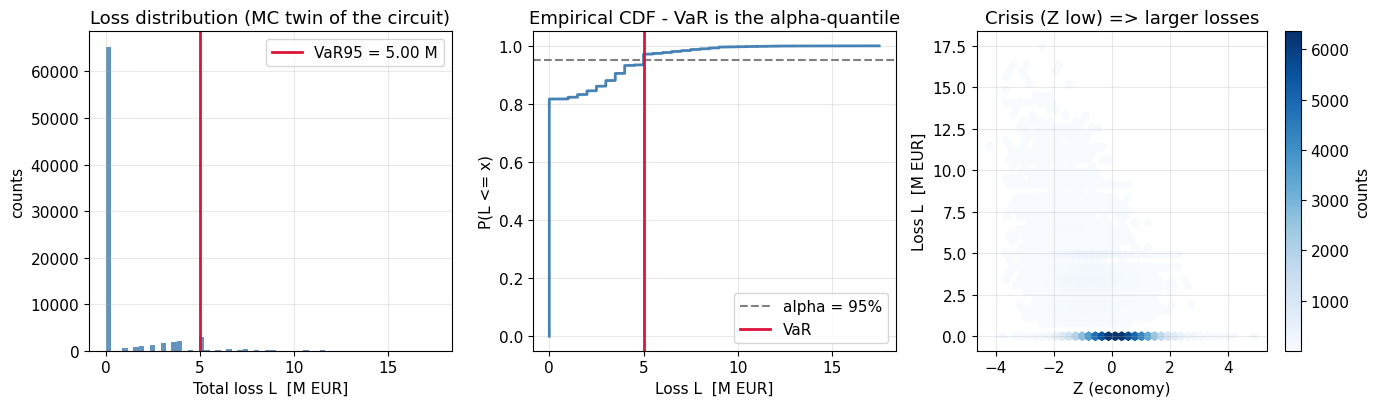

In [8]:
# --- Charts: loss histogram, CDF, and Z vs loss ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

ax = axes[0]
ax.hist(L / 1e6, bins=60, color='steelblue', alpha=0.85, edgecolor='none')
ax.axvline(var_true / 1e6, color='crimson', lw=2, label=f'VaR95 = {var_true/1e6:.2f} M')
ax.set_xlabel('Total loss L  [M EUR]')
ax.set_ylabel('counts')
ax.set_title('Loss distribution (MC twin of the circuit)')
ax.legend()

ax = axes[1]
sorted_L = np.sort(L)
cdf = np.arange(1, len(sorted_L) + 1) / len(sorted_L)
ax.plot(sorted_L / 1e6, cdf, lw=2, color='steelblue')
ax.axhline(ALPHA, color='gray', ls='--', label='alpha = 95%')
ax.axvline(var_true / 1e6, color='crimson', lw=2, label='VaR')
ax.set_xlabel('Loss L  [M EUR]')
ax.set_ylabel('P(L <= x)')
ax.set_title('Empirical CDF - VaR is the alpha-quantile')
ax.legend(loc='lower right')

ax = axes[2]
hb = ax.hexbin(Z, L / 1e6, gridsize=40, cmap='Blues', mincnt=1)
ax.set_xlabel('Z (economy)')
ax.set_ylabel('Loss L  [M EUR]')
ax.set_title('Crisis (Z low) => larger losses')
fig.colorbar(hb, ax=ax, label='counts')

plt.tight_layout()
plt.show()


### What these three plots are saying

- **Left.** Most scenarios have small loss; a long right tail is the credit-risk story.
  The red line is VaR -- only ~5% of mass sits to its right.
- **Middle.** Same information as a CDF. VaR = where the curve crosses 95%.
- **Right.** When $Z$ is negative (crisis), losses pile up. That is the correlation
  channel the paper encodes with formula (11) and the controlled $R_y$ gates.


## 14. Simulating the role of $A$: estimate $a = P(L \le x)$ then search VaR

Classically, $a(x) = \mathbb{E}[\mathbf{1}_{L \le x}]$ is a sample mean of indicators.
In the quantum circuit, that same number sits in the objective-qubit amplitude.
Below we:

1. plot $a(x)$ vs threshold $x$;
2. run a binary search that only looks at noisy estimates of $a(x)$
   (Monte Carlo stand-in for AE), recovering VaR.


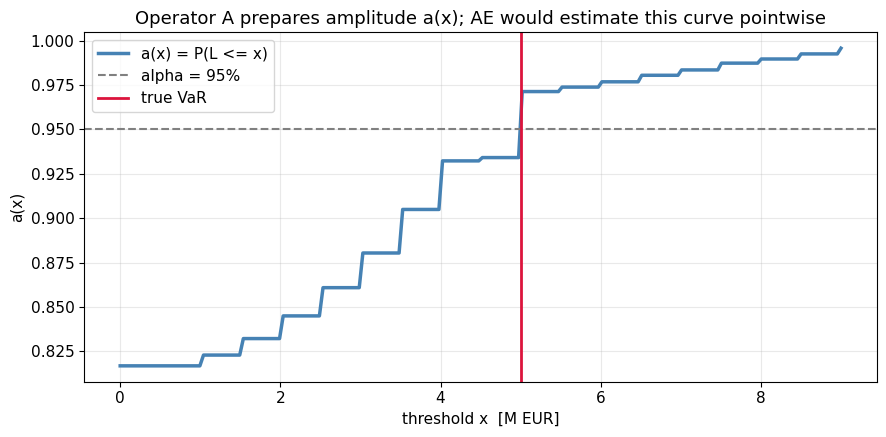

In [9]:
def a_of_x(x, losses):
    # True CDF value a(x) = P(L <= x) from the full MC pool
    return float(np.mean(losses <= x))


def estimate_a_mc(x, losses, n_samples, rng_local):
    # Classical stand-in for one AE call: subsample indicators
    idx = rng_local.integers(0, len(losses), size=n_samples)
    return float(np.mean(losses[idx] <= x))


x_grid = np.linspace(0, np.quantile(L, 0.995), 200)
a_grid = np.array([a_of_x(x, L) for x in x_grid])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_grid / 1e6, a_grid, lw=2.5, color='steelblue', label='a(x) = P(L <= x)')
ax.axhline(ALPHA, color='gray', ls='--', label='alpha = 95%')
ax.axvline(var_true / 1e6, color='crimson', lw=2, label='true VaR')
ax.set_xlabel('threshold x  [M EUR]')
ax.set_ylabel('a(x)')
ax.set_title('Operator A prepares amplitude a(x); AE would estimate this curve pointwise')
ax.legend()
plt.tight_layout()
plt.show()


True VaR_95%              = 5.000 M
Search + CDF estimates    = 4.447 M
|error|                   = 0.553 M
iterations                = 8  (budget 256 samples / eval)


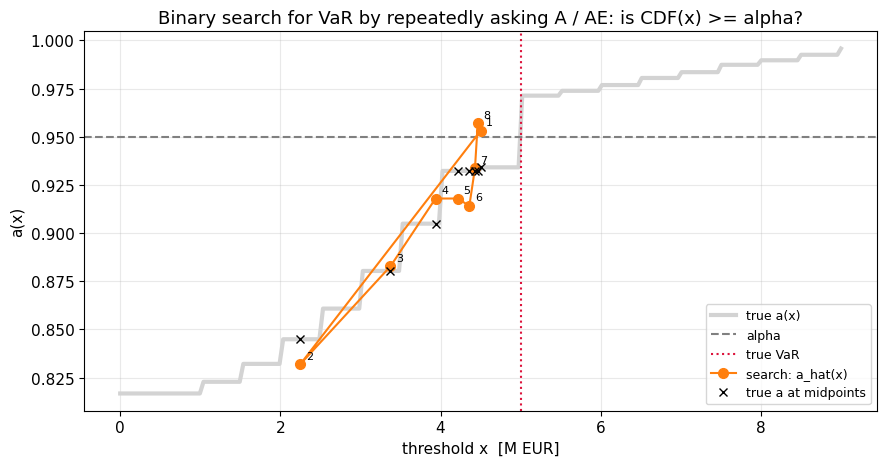

In [10]:
def estimate_var_by_search(losses, alpha_level, budget, rng_local, tol=0.05e6, max_iter=40):
    # Binary search for VaR using noisy CDF estimates (MC stand-in for AE)
    lo = float(np.quantile(losses, 0.80))
    hi = float(np.quantile(losses, 0.995))
    history = []
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        a_true = a_of_x(mid, losses)
        a_hat = estimate_a_mc(mid, losses, budget, rng_local)
        history.append((mid, a_hat, a_true))
        if a_hat < alpha_level:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi), history


BUDGET = 256
var_hat, hist = estimate_var_by_search(L, ALPHA, BUDGET, rng)

print(f'True VaR_95%              = {var_true/1e6:.3f} M')
print(f'Search + CDF estimates    = {var_hat/1e6:.3f} M')
print(f'|error|                   = {abs(var_hat - var_true)/1e6:.3f} M')
print(f'iterations                = {len(hist)}  (budget {BUDGET} samples / eval)')

mids = np.array([h[0] for h in hist])
a_hats = np.array([h[1] for h in hist])
a_trues = np.array([h[2] for h in hist])

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x_grid / 1e6, a_grid, color='lightgray', lw=3, label='true a(x)')
ax.axhline(ALPHA, color='gray', ls='--', label='alpha')
ax.axvline(var_true / 1e6, color='crimson', ls=':', lw=1.5, label='true VaR')
ax.plot(mids / 1e6, a_hats, 'o-', color='C1', lw=1.5, ms=7, label='search: a_hat(x)')
ax.plot(mids / 1e6, a_trues, 'x', color='black', ms=6, label='true a at midpoints')
for i, (m, ah) in enumerate(zip(mids, a_hats)):
    ax.annotate(str(i + 1), (m / 1e6, ah), textcoords='offset points',
                xytext=(4, 4), fontsize=8)
ax.set_xlabel('threshold x  [M EUR]')
ax.set_ylabel('a(x)')
ax.set_title('Binary search for VaR by repeatedly asking A / AE: is CDF(x) >= alpha?')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 15. The mental picture to keep

```text
                 Z
         "how is the economy?"
                 |
                 v
                 U
                 |
                 v
        default probabilities p_k(z)
                 |
        +--------+--------+
        v        v        v
       X1       X2  ...  XK
        \        |        /
         \       |       /
          +------+------+
                 |
                 v
                 S
          sum of losses
                 |
                 v
                 L
                 |
                 v
                 C
          L <= threshold x ?
              /        \
            yes         no
             |           |
            |1>         |0>
                 |
                 v
                AE
                 |
                 v
           P(L <= x)
                 |
                 v
     smallest x with P >= alpha
                 |
                 v
               VaR
```

### Six steps (the paper's pipeline)

1. **Generate scenarios:** $Z \rightarrow X_1,\ldots,X_K$
2. **Compute loss:** $X \rightarrow L = \sum \lambda_k X_k$
3. **Ask a yes/no question:** $L \le x$?
4. **Turn the answer into an amplitude:** $P(\mathrm{obj}=1)=P(L\le x)$
5. **Estimate with AE**
6. **Search** the smallest $x$ with that probability $\ge \alpha$ -> $\mathrm{VaR}_\alpha$

### Versus classical Monte Carlo

| | Classical MC | Quantum (ideal AE) |
|--|--|--|
| Scenarios | sample one-by-one | superposition inside $U$ |
| CDF estimate | mean of indicators, error $\sim 1/\sqrt{M}$ | amplitude estimation, error $\sim 1/M$ |
| VaR | quantile of samples / search on CDF | same search, cheaper CDF evaluations |

### One sentence

**$U$ creates scenarios -> $S$ sums losses -> $C$ asks "is loss under $x$?" -> AE counts how often yes -> search the smallest $x$ with 95% -> that is VaR.**

That sentence is the bridge between
`02_amplitude_estimation.ipynb` / `03_var_with_amplitude_estimation.ipynb`
and this credit-risk construction of operator $A$.


### Ideas to explore next

- Replace the Gaussian one-factor model with Student-$t$ / t-copula (fatter joint tails).
- Estimate **Expected Shortfall** $E[L \mid L > \mathrm{VaR}]$ -- also an expectation, hence AE-friendly.
- Implement a tiny Qiskit version with $K=2$ names, a 1-qubit $Z$, and an explicit $S$ adder.
- Read Egger / Woerner / Goldman market-risk papers side by side with this notebook
  (`../tesi/papers/L2B_risk/`).
